In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("insurance.csv")

print("First 5 rows:")
display(df.head())

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
print("\nLast 5 rows:")
display(df.tail())

print("\nNumber of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()


Last 5 rows:


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



Number of rows and columns:
(1338, 7)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate records:
1


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Variables:")
print(numerical_cols)

print("\nCategorical Variables:")
print(categorical_cols)

In [15]:
print("Missing values before:")
print(df.isnull().sum())

# Fill numerical missing values with median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after:")
print(df.isnull().sum())

Missing values before:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Missing values after:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [14]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 1
Duplicates after: 0


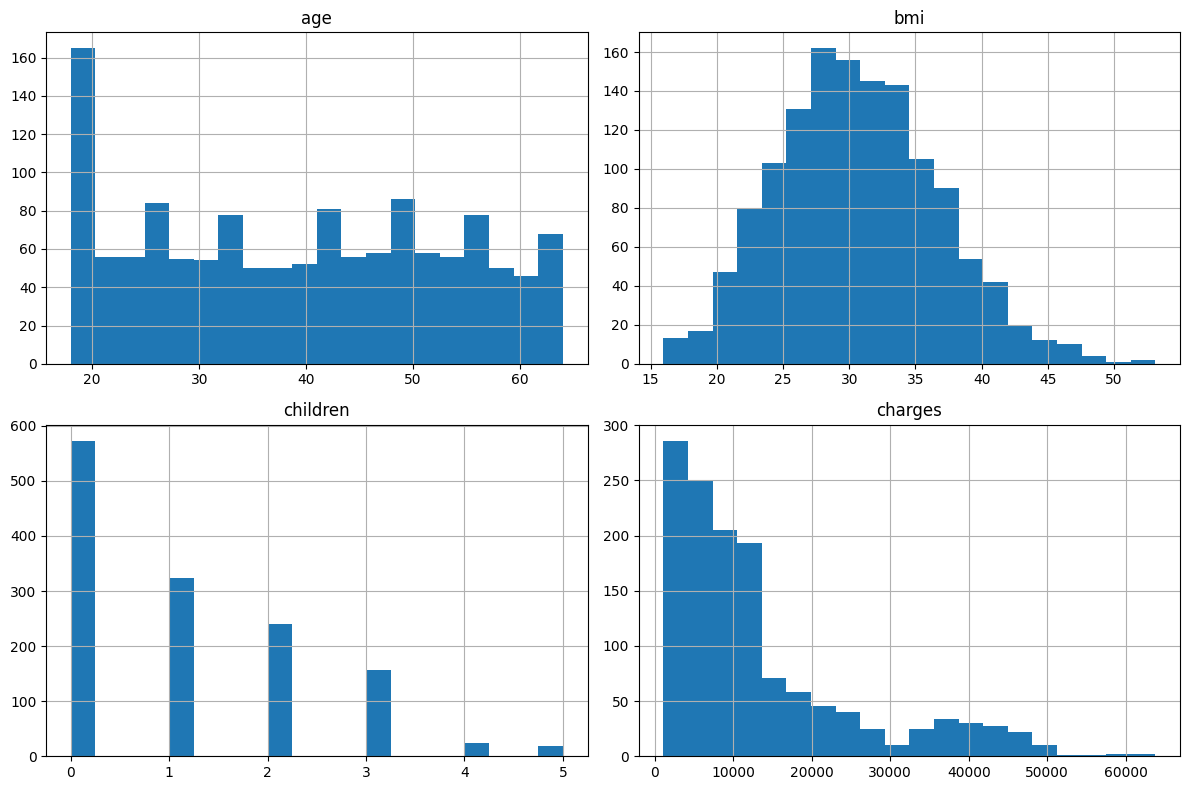

In [16]:
df[numerical_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

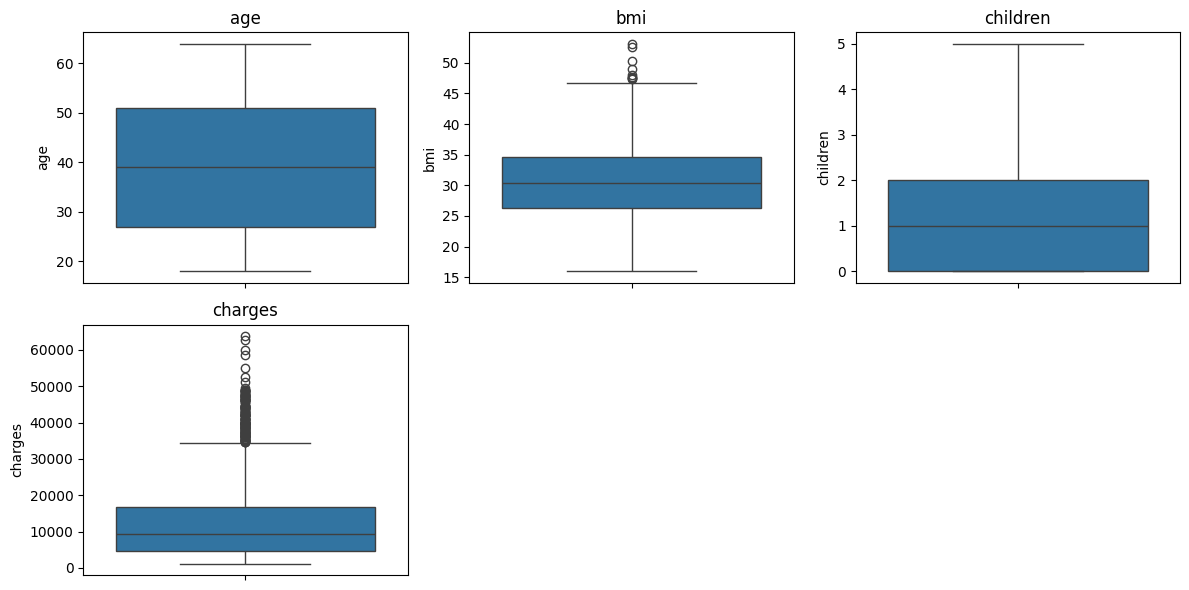

In [17]:
plt.figure(figsize=(12, 6))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

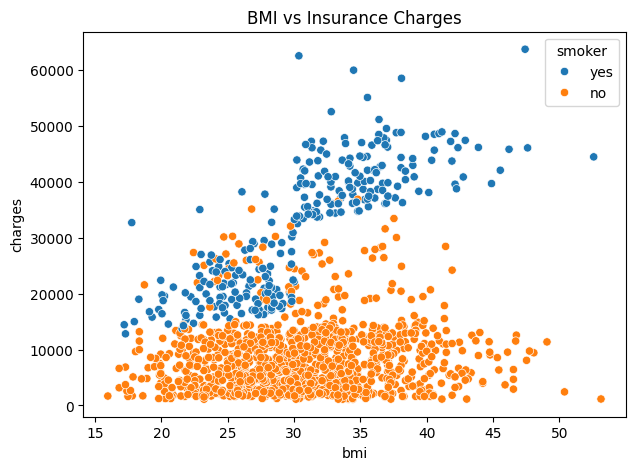

In [18]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Insurance Charges")
plt.show()

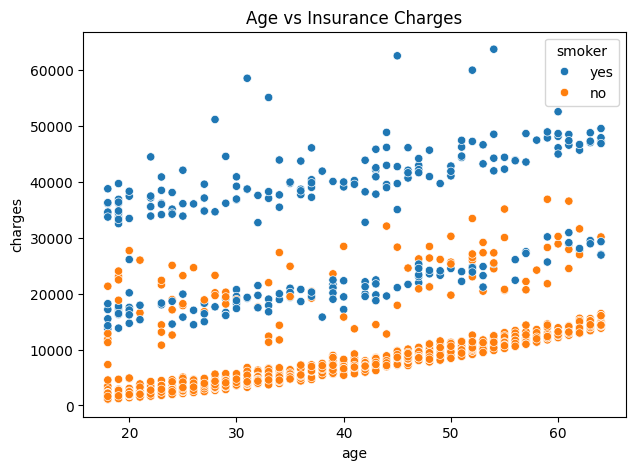

In [19]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Insurance Charges")
plt.show()

In [20]:
df_encoded = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

print(df_encoded.head())

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


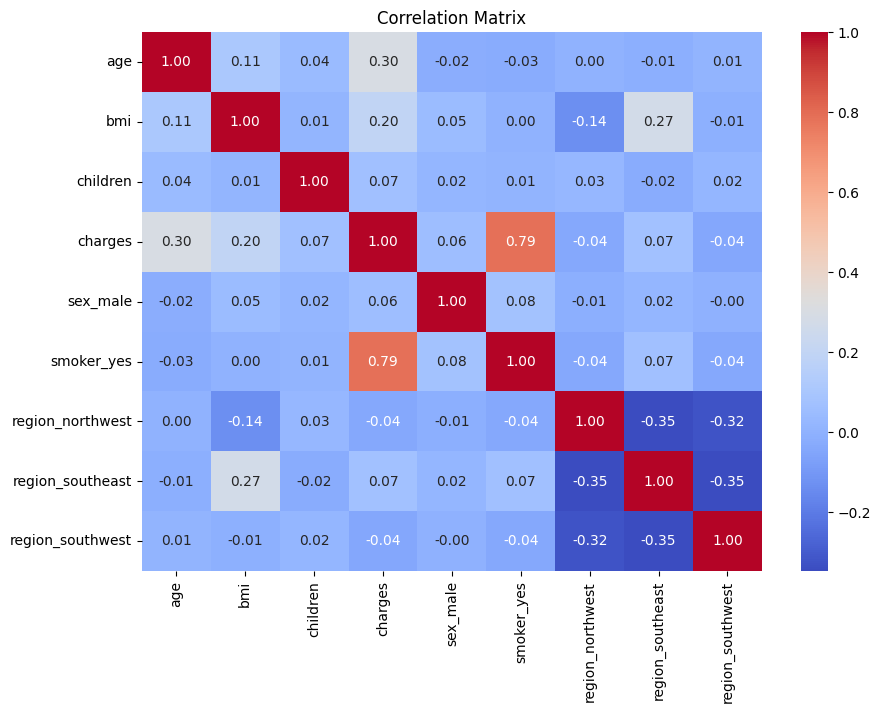

In [21]:
plt.figure(figsize=(10, 7))

correlation = df_encoded.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [22]:
covariance = df_encoded.cov()

print("Covariance Matrix:")
display(covariance)

Covariance Matrix:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
age,197.243282,9.368233,0.703268,5.073683e+04,-0.139180,-0.145109,0.009002,-0.076990,0.056740
bmi,9.368233,37.215715,0.093805,1.465763e+04,0.141568,0.009228,-0.356002,0.733595,-0.016259
children,0.703268,0.093805,1.453402,9.838780e+02,0.010762,0.003569,0.013459,-0.012611,0.011142
charges,50736.833698,14657.628526,983.878025,1.466608e+08,351.584753,3849.763649,-200.870455,396.773609,-226.766344
sex_male,-0.139180,0.141568,0.010762,3.515848e+02,0.250163,0.015470,-0.002676,0.003915,-0.000808
smoker_yes,-0.145109,0.009228,0.003569,3.849764e+03,0.015470,0.163059,-0.006287,0.012278,-0.006440
region_northwest,0.009002,-0.356002,0.013459,-2.008705e+02,-0.002676,-0.006287,0.183745,-0.066025,-0.058951
region_southeast,-0.076990,0.733595,-0.012611,3.967736e+02,0.003915,0.012278,-0.066025,0.198279,-0.066229
region_southwest,0.056740,-0.016259,0.011142,-2.267663e+02,-0.000808,-0.006440,-0.058951,-0.066229,0.184131


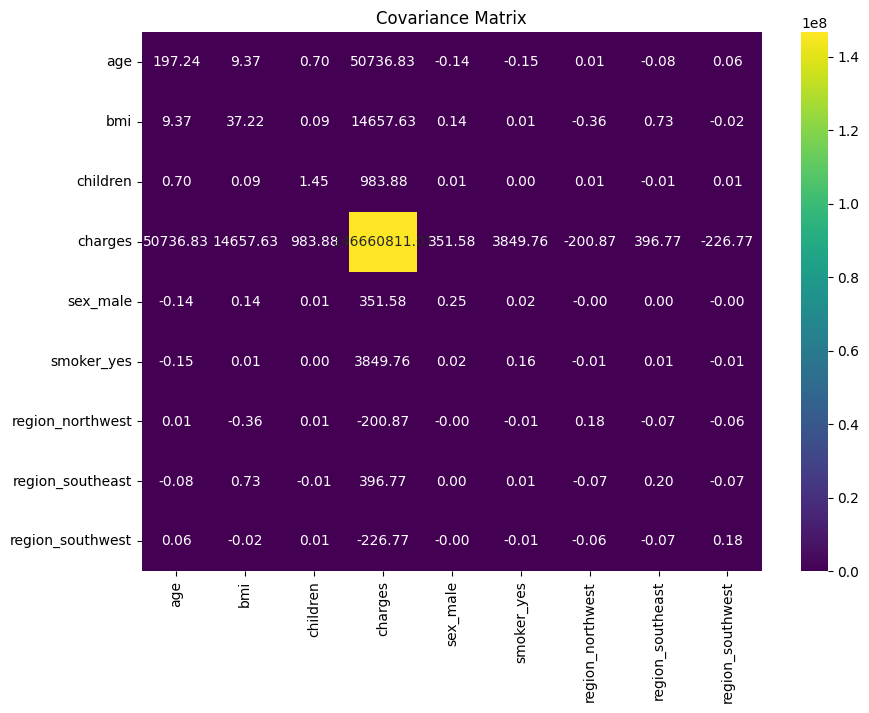

In [23]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    covariance,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Covariance Matrix")
plt.show()

In [24]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1069, 8)
Testing data: (268, 8)


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, y_pred_linear)
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print("Multiple Linear Regression")
print("R2 Score:", linear_r2)
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)

Multiple Linear Regression
R2 Score: 0.8069287081198011
MAE: 4177.045561036319
RMSE: 5956.342894363588


In [27]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge Regression")
print("R2 Score:", ridge_r2)
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)

Ridge Regression
R2 Score: 0.8059553507246429
MAE: 4194.009577324494
RMSE: 5971.338292131439


In [28]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression")
print("R2 Score:", lasso_r2)
print("MAE:", lasso_mae)
print("RMSE:", lasso_rmse)

Lasso Regression
R2 Score: 0.8069216664782433
MAE: 4177.130359466576
RMSE: 5956.451512400036


In [29]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_r2 = r2_score(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree Regression")
print("R2 Score:", dt_r2)
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)

Decision Tree Regression
R2 Score: 0.8940896757972968
MAE: 2656.8390786583914
RMSE: 4411.537636335603


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Regression")
print("R2 Score:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest Regression
R2 Score: 0.8796611113027272
MAE: 2637.9945481492537
RMSE: 4702.4462291546515


In [31]:
results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

display(results)

,Model,R2 Score,MAE,RMSE
3,Decision Tree,0.894090,2656.839079,4411.537636
4,Random Forest,0.879661,2637.994548,4702.446229
0,Multiple Linear Regression,0.806929,4177.045561,5956.342894
2,Lasso Regression,0.806922,4177.130359,5956.451512
1,Ridge Regression,0.805955,4194.009577,5971.338292


In [32]:
best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Decision Tree


In [33]:
import joblib

joblib.dump(rf_model, "best_insurance_model.pkl")

# Save feature names also
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model saved successfully!")

Model saved successfully!


In [34]:
import os

print(os.path.exists("best_insurance_model.pkl"))
print(os.path.exists("feature_columns.pkl"))

True
True


In [35]:
!pip install -q gradio

In [36]:
import joblib
import gradio as gr

model = joblib.load("best_insurance_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

In [37]:
def predict_insurance(
    age,
    sex,
    bmi,
    children,
    smoker,
    region
):

    # Create input dataframe
    input_data = pd.DataFrame({
        "age": [age],
        "bmi": [bmi],
        "children": [children],
        "sex_male": [1 if sex == "male" else 0],
        "smoker_yes": [1 if smoker == "yes" else 0],
        "region_northwest": [1 if region == "northwest" else 0],
        "region_southeast": [1 if region == "southeast" else 0],
        "region_southwest": [1 if region == "southwest" else 0]
    })

    # Make sure columns match training data
    input_data = input_data.reindex(
        columns=feature_columns,
        fill_value=0
    )

    prediction = model.predict(input_data)[0]

    return f"Predicted Insurance Cost: ${prediction:,.2f}"

In [38]:
interface = gr.Interface(
    fn=predict_insurance,

    inputs=[
        gr.Number(label="Age"),
        gr.Dropdown(
            ["male", "female"],
            label="Sex"
        ),
        gr.Number(label="BMI"),
        gr.Number(label="Children"),
        gr.Dropdown(
            ["yes", "no"],
            label="Smoker"
        ),
        gr.Dropdown(
            ["northeast", "northwest", "southeast", "southwest"],
            label="Region"
        )
    ],

    outputs=gr.Textbox(
        label="Prediction"
    ),

    title="Medical Insurance Cost Prediction",

    description="Enter patient details to predict medical insurance cost."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a669645332bf408beb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
